# Chapter 2: Convex Hulls

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 2, printed pages 38-64 (PDF pages 53-79).

**Chapter goal.** Learn convex hulls as both a geometric object and an algorithmic problem: a hull is the smallest convex set containing the input, a certificate of extreme points, and a place where support lines, sorting, orientation predicates, lower bounds, divide-and-conquer, and 3D faces all meet.

This notebook is source-grounded but original. It follows the chapter topics from convexity through incremental construction, gift wrapping, Graham scan, lower bounds, divide-and-conquer, and spatial hulls without reproducing textbook prose or figures.


## Computational Translation Guide

| Chapter idea | Computational representation | Inspection target |
| --- | --- | --- |
| convex set and convex hull | barycentric combinations and `scipy.spatial.ConvexHull` | every convex combination stays inside the hull polygon |
| support line | oriented line with all points on one side | sign of orientation predicates |
| incremental construction | add points one at a time and repair extreme chain | how the hull changes only near visible edges |
| gift wrapping | choose the next most counterclockwise point | one edge is certified by all other points lying to the same side |
| Graham scan | sorted points and a stack | right turns are popped until convexity returns |
| lower bound | reduction from sorting/order recovery | why output-in-order costs comparisons |
| divide and conquer | left/right hulls plus bridge tangents | tangent lines separate subhulls |
| 3D hull | triangular facets and Euler check | vertices, edges, and faces satisfy the polyhedral ledger |


## Visual Storyboard

1. **Convex combination board.** Plot points, their hull, and a grid of convex combinations to make the definition inspectable.
2. **Algorithm snapshot panel.** Compare incremental hull growth, gift wrapping, and Graham scan stack behavior using the same point set.
3. **Predicate and lower-bound ledger.** Draw orientation certificates and a reduction graph from sorting to ordered hull output.
4. **Divide-and-conquer tangent merge.** Split points, build two hulls, and highlight bridge tangents.
5. **3D hull surface view.** Render a small spatial hull and check its facet counts against Euler's formula.


In [1]:
from pathlib import Path
import sys, json, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import networkx as nx
from scipy.spatial import ConvexHull
from IPython.display import display, Markdown

BOOK_ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY = 'chapter-02-convex-hulls'
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, TABLES, CHECKS = ARTIFACT_ROOT/'figures', ARTIFACT_ROOT/'tables', ARTIFACT_ROOT/'checks'
artifact_paths = []
plt.rcParams.update({'figure.figsize': (7,5), 'axes.grid': True})


## Source Coverage And Library Routing

The chapter's mathematical spine is finite and visual: convex combinations define the hull, orientation predicates certify support lines, and algorithms differ by how they discover the extreme cycle. `scipy.spatial.ConvexHull` is used as a reference implementation and for 3D facets; Matplotlib handles durable diagrams; NetworkX is used only where the chapter's lower-bound logic is naturally a directed reduction. The notebook keeps the algorithm code visible so the hull is not a black-box call.


In [2]:
source_coverage = {
    'convexity and convex combinations': True,
    'convex hull definition': True,
    'incremental construction': True,
    'algorithm analysis vocabulary': True,
    'gift wrapping': True,
    'Graham scan': True,
    'sorting lower bound': True,
    'divide and conquer tangents': True,
    '3D convex hulls': True,
}
library_rows = [
    {'concept':'convex combinations', 'representation':'barycentric samples in a triangle', 'library':'NumPy + Matplotlib', 'check':'all weights nonnegative and sum to one'},
    {'concept':'planar hull algorithms', 'representation':'visible orientation predicates and stack traces', 'library':'plain Python + Matplotlib', 'check':'algorithm hull equals SciPy hull'},
    {'concept':'lower bound', 'representation':'directed reduction graph', 'library':'NetworkX', 'check':'sorting reaches ordered hull output'},
    {'concept':'3D hull', 'representation':'triangular facet surface', 'library':'SciPy ConvexHull + Matplotlib 3D', 'check':'V-E+F=2'},
]
source_coverage_path = save_json({'source_span':'printed pages 38-64, PDF pages 53-79', 'coverage':source_coverage}, CHECKS/'source-coverage.json')
library_table = save_csv(library_rows, TABLES/'library-routing.csv')
artifact_paths.extend([source_coverage_path, library_table])


## 1. Convexity And Convex Combinations

A convex hull can be read in two equivalent ways. It is the smallest convex set containing the points, and it is the set of all convex combinations of those points. The visual below samples combinations of three selected points inside a larger cloud. The hull boundary is drawn from the whole set, while the blue samples show why nonnegative weights summing to one stay inside the triangle spanned by their anchors.


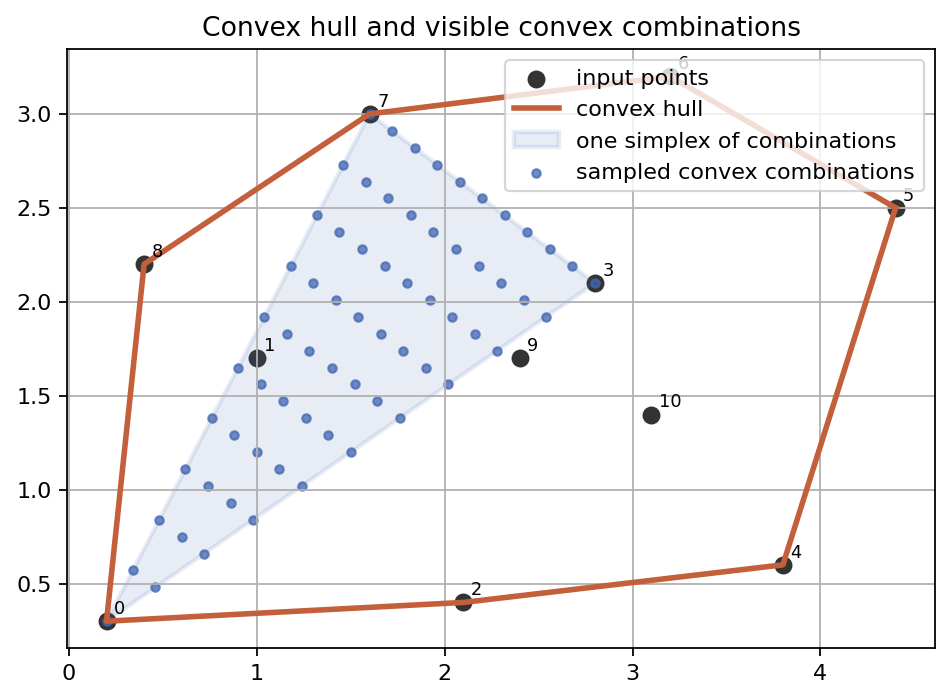

In [3]:
points = np.array([
    [0.2, 0.3], [1.0, 1.7], [2.1, 0.4], [2.8, 2.1], [3.8, 0.6],
    [4.4, 2.5], [3.2, 3.2], [1.6, 3.0], [0.4, 2.2], [2.4, 1.7], [3.1, 1.4]
])
hull = ConvexHull(points)
hull_cycle = list(hull.vertices) + [hull.vertices[0]]
anchors = points[[0, 3, 7]]
weights = []
combo_points = []
for i in range(11):
    for j in range(11-i):
        a = i/10
        b = j/10
        c = 1-a-b
        weights.append((a,b,c))
        combo_points.append(a*anchors[0] + b*anchors[1] + c*anchors[2])
combo_points = np.array(combo_points)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(points[:,0], points[:,1], s=50, color='#333333', label='input points')
ax.plot(points[hull_cycle,0], points[hull_cycle,1], color='#c45f3c', linewidth=2.5, label='convex hull')
ax.add_patch(MplPolygon(anchors, closed=True, facecolor='#4267b2', alpha=0.12, edgecolor='#4267b2', linewidth=2, label='one simplex of combinations'))
ax.scatter(combo_points[:,0], combo_points[:,1], s=14, color='#4267b2', alpha=0.75, label='sampled convex combinations')
for idx, p in enumerate(points):
    ax.text(p[0]+0.04, p[1]+0.04, str(idx), fontsize=8)
ax.set_aspect('equal')
ax.set_title('Convex hull and visible convex combinations')
ax.legend(loc='upper right')
combo_plot = save_matplotlib(fig, FIGURES/'convex-combination-board.png')
plt.close(fig)

combo_check = save_json({
    'hull_vertices': hull.vertices.tolist(),
    'sampled_weights_sum_to_one': bool(all(abs(sum(w)-1) < 1e-12 for w in weights)),
    'sampled_weights_nonnegative': bool(all(min(w) >= -1e-12 for w in weights)),
    'sample_count': int(len(combo_points)),
}, CHECKS/'convex-combination-checks.json')
artifact_paths.extend([combo_plot, combo_check])
display_artifact(combo_plot, width=760)


## 2. Incremental Hulls, Gift Wrapping, And Graham Scan

All three planar algorithms rely on the same primitive: orientation. The determinant sign says whether a triple of points makes a left turn, right turn, or collinear step. Gift wrapping uses that sign to certify one support edge at a time. Graham scan sorts angularly and maintains a stack, popping a point whenever the newest triple turns the wrong way. Incremental construction can be understood as repeatedly asking which old hull edges are visible from the new point.


C:\Users\rahul\AppData\Local\Temp\ipykernel_33424\2284226060.py:2: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(b-a, c-a))


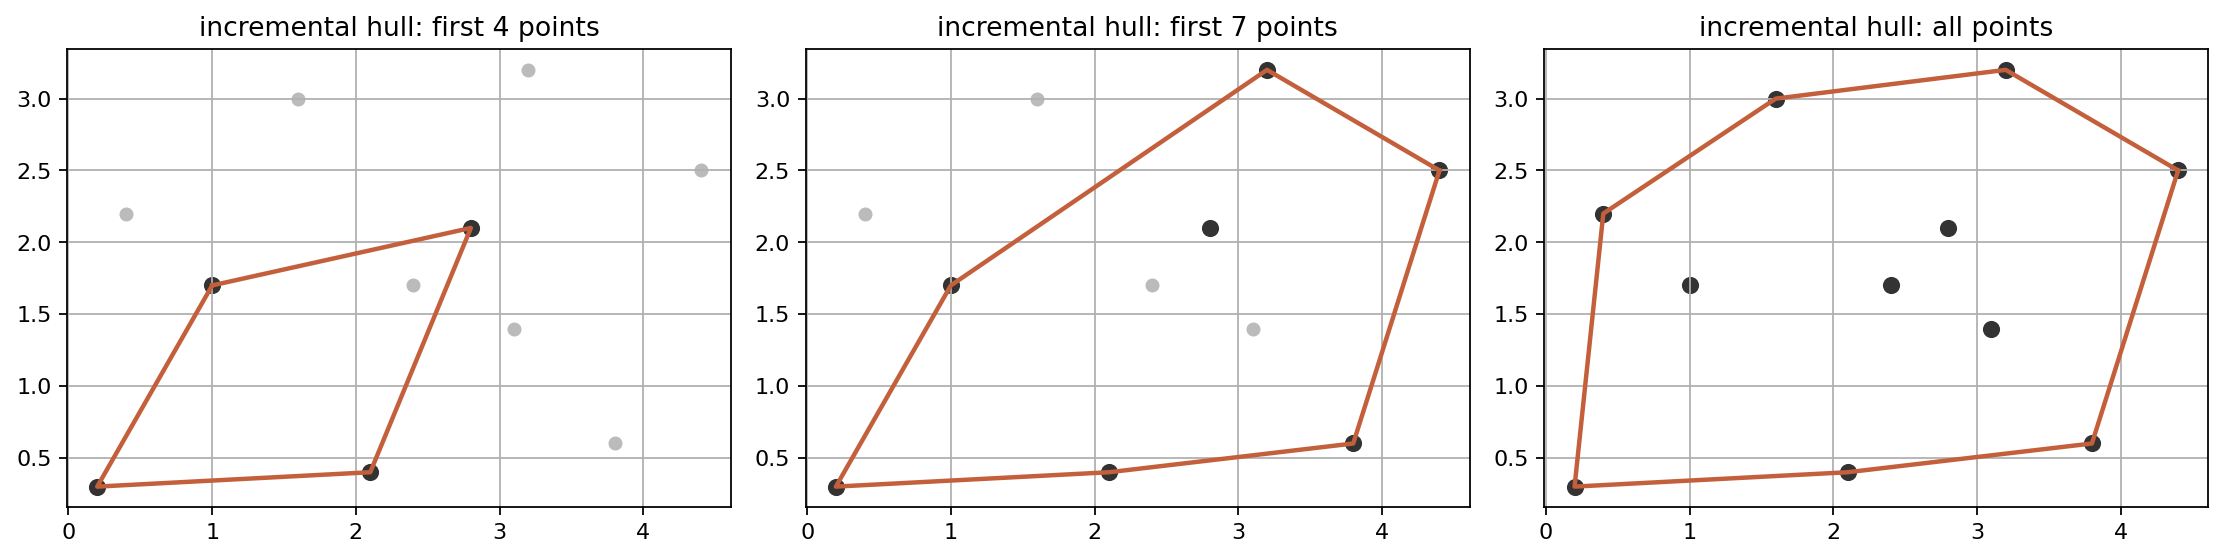

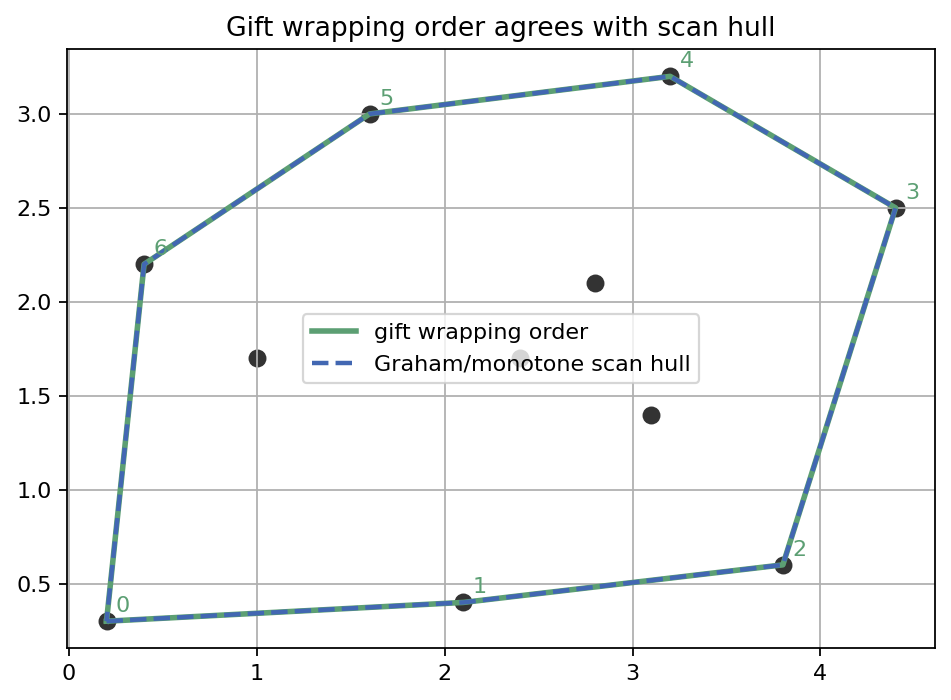

In [4]:
def orient(a, b, c):
    return float(np.cross(b-a, c-a))

def monotone_chain(pts):
    ordered = sorted(map(tuple, pts))
    lower = []
    for p in ordered:
        p = np.array(p, dtype=float)
        while len(lower) >= 2 and orient(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
    upper = []
    for p in reversed(ordered):
        p = np.array(p, dtype=float)
        while len(upper) >= 2 and orient(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
    return np.array(lower[:-1] + upper[:-1])

def gift_wrap(pts):
    start = min(range(len(pts)), key=lambda i: (pts[i,0], pts[i,1]))
    hull_indices = []
    current = start
    while True:
        hull_indices.append(current)
        candidate = 0 if current != 0 else 1
        for k in range(len(pts)):
            if k == current or k == candidate:
                continue
            if orient(pts[current], pts[candidate], pts[k]) < 0:
                candidate = k
        current = candidate
        if current == start:
            break
    return hull_indices

scan_hull = monotone_chain(points)
gift_indices = gift_wrap(points)
scipy_cycle = points[hull.vertices]
scan_set = {tuple(np.round(p, 8)) for p in scan_hull}
scipy_set = {tuple(np.round(p, 8)) for p in scipy_cycle}

snapshots = [points[:4], points[:7], points]
fig, axes = plt.subplots(1, 3, figsize=(14,4.5))
for ax, subset, title in zip(axes, snapshots, ['first 4 points', 'first 7 points', 'all points']):
    ax.scatter(points[:,0], points[:,1], color='#bbbbbb', s=28)
    ax.scatter(subset[:,0], subset[:,1], color='#333333', s=45)
    if len(subset) >= 3:
        sub_hull = ConvexHull(subset)
        cyc = list(sub_hull.vertices) + [sub_hull.vertices[0]]
        ax.plot(subset[cyc,0], subset[cyc,1], color='#c45f3c', linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(f'incremental hull: {title}')
fig.tight_layout()
incremental_plot = save_matplotlib(fig, FIGURES/'incremental-hull-snapshots.png')
plt.close(fig)

fig, ax = plt.subplots(figsize=(7,5.5))
ax.scatter(points[:,0], points[:,1], s=50, color='#333333')
cycle_indices = gift_indices + [gift_indices[0]]
ax.plot(points[cycle_indices,0], points[cycle_indices,1], color='#5c9f73', linewidth=2.5, label='gift wrapping order')
ax.plot(np.r_[scan_hull[:,0], scan_hull[0,0]], np.r_[scan_hull[:,1], scan_hull[0,1]], '--', color='#4267b2', linewidth=2, label='Graham/monotone scan hull')
for i in range(len(gift_indices)):
    p = points[gift_indices[i]]
    ax.text(p[0]+0.05, p[1]+0.05, f'{i}', color='#5c9f73', fontsize=10)
ax.set_aspect('equal')
ax.set_title('Gift wrapping order agrees with scan hull')
ax.legend()
algorithm_plot = save_matplotlib(fig, FIGURES/'gift-wrap-and-scan-certificates.png')
plt.close(fig)

algorithm_check = save_json({
    'gift_wrap_vertices': gift_indices,
    'scan_vertex_count': int(len(scan_hull)),
    'scipy_vertex_count': int(len(hull.vertices)),
    'scan_matches_scipy_vertex_set': scan_set == scipy_set,
    'orientation_certificate_min_margin': min(abs(orient(points[gift_indices[i-1]], points[gift_indices[i]], points[gift_indices[(i+1)%len(gift_indices)]])) for i in range(len(gift_indices))),
}, CHECKS/'planar-hull-algorithm-checks.json')
artifact_paths.extend([incremental_plot, algorithm_plot, algorithm_check])
display_artifact(incremental_plot, width=900)
display_artifact(algorithm_plot, width=760)


## 3. Lower Bound And Divide-And-Conquer Merge

The chapter's lower-bound discussion asks us to separate output size from the information needed to identify and order the hull. In comparison-based settings, sorted order can be encoded as a hull-output task, so an algorithm that outputs the hull in cyclic order cannot beat the corresponding sorting lower bound in general. Divide-and-conquer responds constructively: solve two smaller hulls, then find bridge tangents and merge.


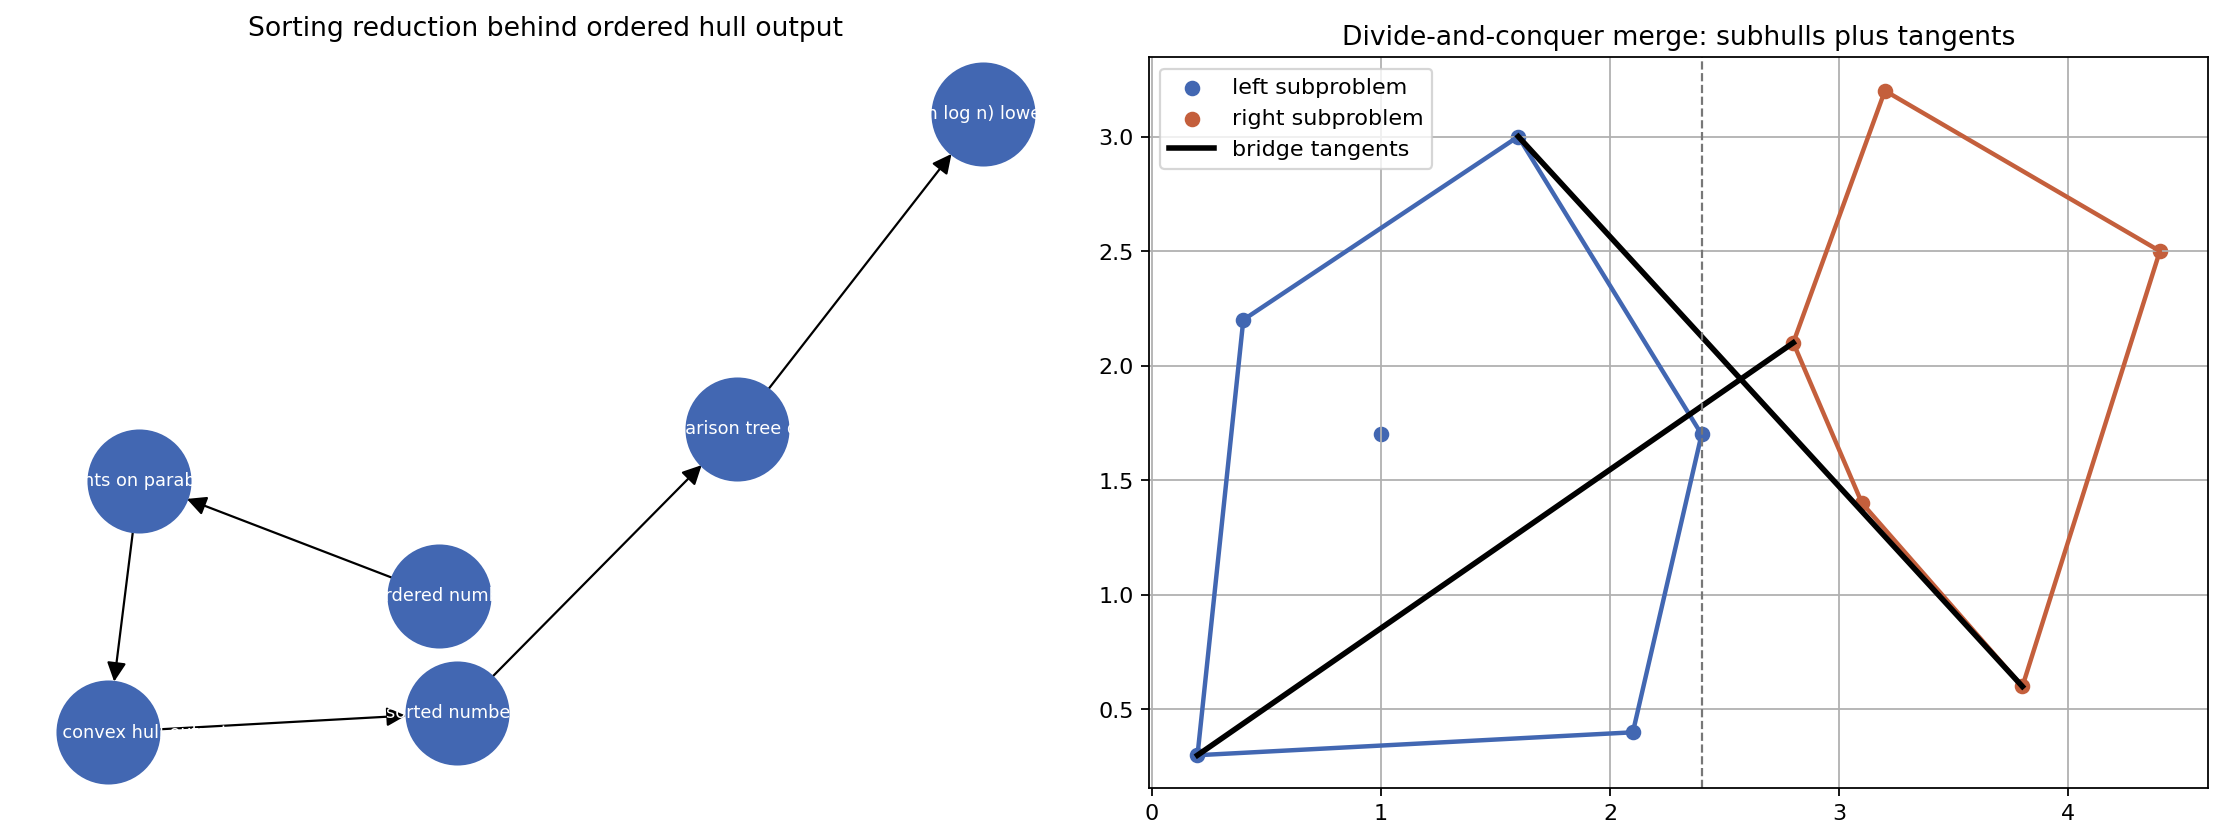

In [5]:
# Reduction graph for the lower-bound logic.
R = nx.DiGraph()
R.add_edges_from([
    ('unordered numbers', 'points on parabola'),
    ('points on parabola', 'ordered convex hull output'),
    ('ordered convex hull output', 'sorted numbers'),
    ('comparison tree depth', 'Omega(n log n) lower bound'),
    ('sorted numbers', 'comparison tree depth'),
])
pos = nx.spring_layout(R, seed=2)
fig, axes = plt.subplots(1, 2, figsize=(14,5.2))
nx.draw_networkx(R, pos, ax=axes[0], node_size=2100, node_color='#4267b2', font_color='white', font_size=8, arrowsize=18)
axes[0].set_title('Sorting reduction behind ordered hull output')
axes[0].axis('off')

left_pts = points[points[:,0] <= 2.4]
right_pts = points[points[:,0] > 2.4]
left_hull = ConvexHull(left_pts)
right_hull = ConvexHull(right_pts)
axes[1].scatter(left_pts[:,0], left_pts[:,1], color='#4267b2', label='left subproblem')
axes[1].scatter(right_pts[:,0], right_pts[:,1], color='#c45f3c', label='right subproblem')
for subset, subhull, color in [(left_pts,left_hull,'#4267b2'), (right_pts,right_hull,'#c45f3c')]:
    cyc = list(subhull.vertices)+[subhull.vertices[0]]
    axes[1].plot(subset[cyc,0], subset[cyc,1], color=color, linewidth=2)
# Hand-picked bridge tangents for this fixed data set.
upper_l, upper_r = left_pts[3], right_pts[1]
lower_l, lower_r = left_pts[0], right_pts[0]
axes[1].plot([upper_l[0], upper_r[0]], [upper_l[1], upper_r[1]], color='black', linewidth=2.5, label='bridge tangents')
axes[1].plot([lower_l[0], lower_r[0]], [lower_l[1], lower_r[1]], color='black', linewidth=2.5)
axes[1].axvline(2.4, color='#777777', linestyle='--', linewidth=1)
axes[1].set_aspect('equal')
axes[1].set_title('Divide-and-conquer merge: subhulls plus tangents')
axes[1].legend(loc='upper left')
fig.tight_layout()
merge_plot = save_matplotlib(fig, FIGURES/'lower-bound-and-merge-tangents.png')
plt.close(fig)

lower_bound_table = save_csv([
    {'claim':'ordered hull output can encode sorting', 'model':'comparison tree', 'consequence':'Omega(n log n)'},
    {'claim':'divide-and-conquer solves two subproblems then merges', 'model':'recurrence', 'consequence':'O(n log n) with linear merge'},
], TABLES/'lower-bound-merge-ledger.csv')
merge_check = save_json({
    'sorting_reaches_ordered_hull_output': bool(nx.has_path(R, 'unordered numbers', 'ordered convex hull output')),
    'ordered_hull_reaches_sorted_numbers': bool(nx.has_path(R, 'ordered convex hull output', 'sorted numbers')),
    'left_hull_vertices': int(len(left_hull.vertices)),
    'right_hull_vertices': int(len(right_hull.vertices)),
}, CHECKS/'lower-bound-merge-checks.json')
artifact_paths.extend([merge_plot, lower_bound_table, merge_check])
display_artifact(merge_plot, width=900)


## 4. Spatial Convex Hulls

In 3D the hull boundary is no longer a cycle of edges. It is a polyhedral surface made of faces. The code below builds a small spatial hull, renders its triangular facets, and counts vertices, edges, and faces. The check is deliberately topological: for a convex polyhedron, the boundary is sphere-like, so `V - E + F = 2`.


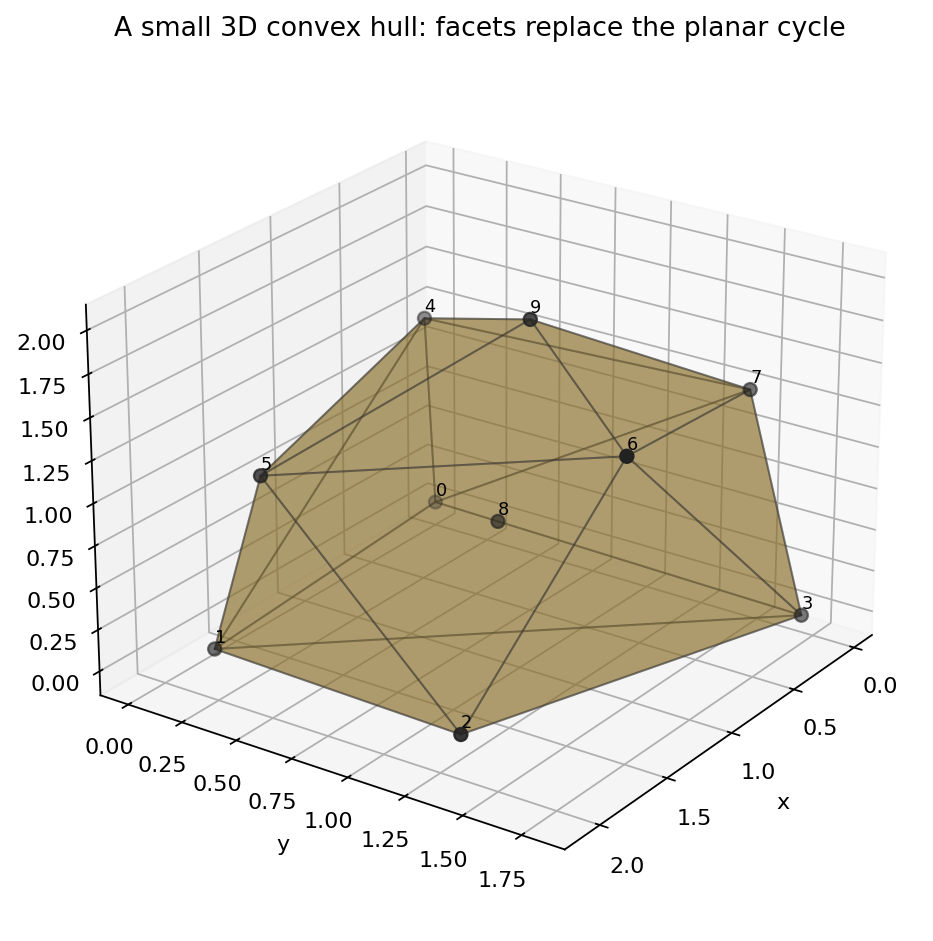

In [6]:
points3 = np.array([
    [0,0,0], [1.8,0.1,0.0], [2.1,1.4,0.2], [0.2,1.8,0.1],
    [0.4,0.2,1.4], [1.9,0.4,1.2], [1.6,1.8,1.7], [0.1,1.5,1.3],
    [1.0,0.9,0.7], [1.1,1.1,2.0]
], dtype=float)
hull3 = ConvexHull(points3)
faces = hull3.simplices
edges = {tuple(sorted((int(a), int(b)))) for face in faces for a,b in itertools.combinations(face, 2)}
V, E, F = len(hull3.vertices), len(edges), len(faces)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
poly = Poly3DCollection(points3[faces], alpha=0.42, facecolor='#8a6f2a', edgecolor='#333333', linewidth=0.9)
ax.add_collection3d(poly)
ax.scatter(points3[:,0], points3[:,1], points3[:,2], color='#222222', s=35)
for i, p in enumerate(points3):
    ax.text(p[0], p[1], p[2]+0.04, str(i), fontsize=8)
ax.set_title('A small 3D convex hull: facets replace the planar cycle')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.view_init(elev=24, azim=35)
fig.tight_layout()
hull3_plot = save_matplotlib(fig, FIGURES/'spatial-convex-hull-facets.png')
plt.close(fig)

hull3_check = save_json({
    'vertices': V,
    'edges': E,
    'triangular_faces': F,
    'euler_characteristic': V - E + F,
    'convex_hull_volume': float(hull3.volume),
}, CHECKS/'spatial-hull-euler-checks.json')
artifact_paths.extend([hull3_plot, hull3_check])
display_artifact(hull3_plot, width=760)


## Applied Lab

Change one point and rerun the algorithm cells. If the point moves inside the current hull, the extreme vertex set should not change. If it moves outside, the orientation certificates and bridge tangents change locally. For the lower-bound graph, reverse one reduction arrow and ask whether the proof still means the same thing; this is a good way to catch the common mistake of treating reductions as undirected analogies.


## Standalone Coverage Note

A convex-hull algorithm should always be read with two certificates in mind. First, every reported hull edge must be a support edge: all input points lie on one side of its oriented line. Second, every omitted point must be explainable as a convex combination or as lying inside the support polygon. This is why the notebook keeps both predicate-level code and a SciPy reference implementation. The lower-bound section is equally important: it prevents the learner from confusing a clever implementation with a proof that no better comparison-based method exists.


## Takeaways

- Convex hulls translate geometry into orientation predicates and support-line certificates.
- Gift wrapping, scan methods, incremental construction, and divide-and-conquer differ in search strategy, not in the underlying convexity invariant.
- Lower bounds are statements about every algorithm in a model, while upper bounds are statements about one algorithm.
- In 3D the hull is a surface, so face and edge bookkeeping replaces the planar cyclic list.


In [7]:
# final_sanity
assert all(source_coverage.values())
assert scan_set == scipy_set
assert nx.has_path(R, 'unordered numbers', 'sorted numbers')
assert V - E + F == 2
assert hull3.volume > 0
assert json.loads(source_coverage_path.read_text())['coverage']['gift wrapping']
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity = {
    'source_coverage_items': len(source_coverage),
    'artifact_count': len(artifact_paths),
    'planar_hull_vertices': int(len(hull.vertices)),
    'spatial_euler_characteristic': int(V - E + F),
    'status': 'passed',
}
final_sanity_path = save_json(final_sanity, CHECKS/'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'source_coverage_items': 9,
 'artifact_count': 12,
 'planar_hull_vertices': 7,
 'spatial_euler_characteristic': 2,
 'status': 'passed'}